In [1]:
# Parameters
megadescriptor_version = 'T-224'  # 'S-224', 'B-224', 'L-384'
detection = '' # '', _detected', '_detected_manual'
seed = 42
query_ratio = 0.2

In [2]:
# Parameters
megadescriptor_version = "L-384"
detection = "_detected_manual"
query_ratio = 0.2
seed = 0


In [3]:
import torch
import numpy as np
import joblib
import torch.nn as nn
import torch.optim as optim
import random
from collections import defaultdict

In [4]:
np.random.seed(seed)

# Path to new file
data_path = f"saved_models/{megadescriptor_version}/data{detection}.npz"
encoder_path = f"saved_models/{megadescriptor_version}/label_encoder{detection}.pkl"

# Load everything at once
data = np.load(data_path)

embeddings = data["embeddings"]      # shape (N, D)
labels = data["label_ids"]           # integer labels
# original_labels = data["labels"]     # string labels (optional)

print("Embeddings shape:", embeddings.shape)

# Optional: load encoder if you want inverse_transform
encoder = joblib.load(encoder_path)
names = encoder.inverse_transform(labels)

encoder = joblib.load(encoder_path)
id_to_name = dict(enumerate(encoder.classes_))
name_to_id = {v: k for k, v in id_to_name.items()}


Embeddings shape: (315, 1536)


In [5]:

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    embeddings, labels, test_size=query_ratio, random_state=seed
)

In [6]:
class Classifier(nn.Module):
    def __init__(self, input_dim=768, num_classes=10, hidden_dim=256, dropout=0.3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, num_classes)
        )

    def forward(self, x):
        return self.net(x)


In [7]:
from proportional_split_xy import proportional_split_xy

# Triplet Loss


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


C:\Users\user\AppData\Local\Temp\ipykernel_17292\1123045260.py:14: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('tab20', num_classes)


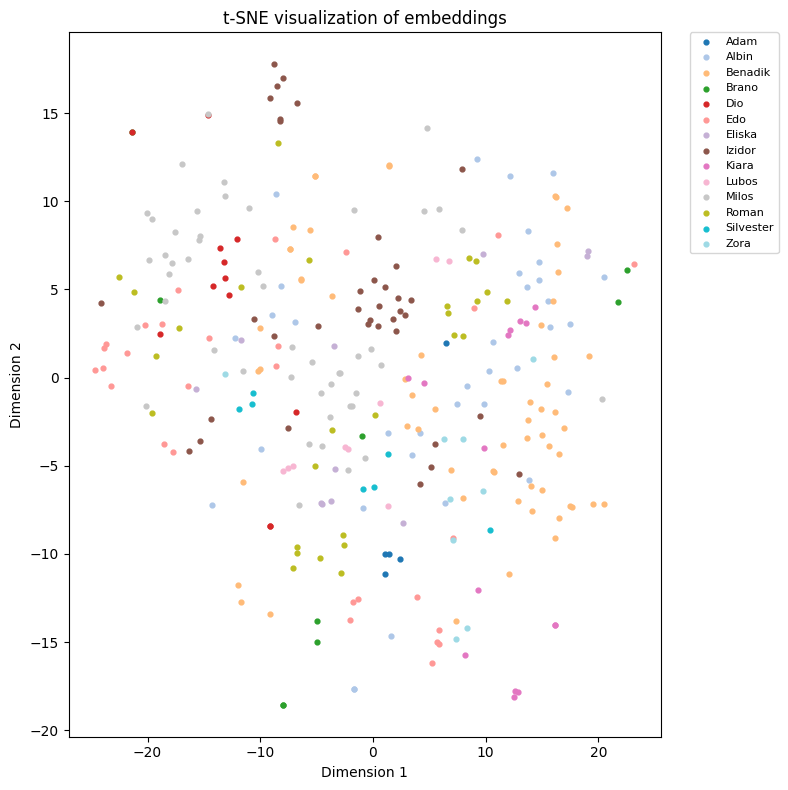

In [9]:
from sklearn.manifold import TSNE

tsne = TSNE(n_components=2, perplexity=30)
emb_2d = tsne.fit_transform(embeddings)

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

unique_labels = np.unique(labels)
num_classes = len(unique_labels)

# Use high-contrast categorical colormap
cmap = cm.get_cmap('tab20', num_classes)

plt.figure(figsize=(8, 8))

for label in unique_labels:
    mask = labels == label
    
    plt.scatter(
        emb_2d[mask, 0],
        emb_2d[mask, 1],
        s=12,
        color=cmap(label),              # use label as color index
        label=id_to_name[label]         # use class name in legend
    )

plt.title("t-SNE visualization of embeddings")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")

plt.legend(
    bbox_to_anchor=(1.05, 1),
    loc='upper left',
    borderaxespad=0.,
    fontsize=8
)

plt.tight_layout()
plt.show()

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred = knn.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("KNN accuracy:", acc)

KNN accuracy: 0.5238095238095238


In [11]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.model_selection import StratifiedShuffleSplit

def evaluate_accuracy_np(embeddings, labels, query_ratio=query_ratio, seed=seed):
    sss = StratifiedShuffleSplit(n_splits=1, test_size=query_ratio, random_state=seed)
    db_idx, q_idx = next(sss.split(embeddings, labels))
    N = len(labels)
    idx = np.arange(N)
    np.random.shuffle(idx)

    split = int(N * (1 - query_ratio))
    db_idx = idx[:split]
    q_idx = idx[split:]

    db_emb = embeddings[db_idx]
    db_labels = labels[db_idx]

    q_emb = embeddings[q_idx]
    q_labels = labels[q_idx]

    # L2 normalize (important for cosine!)
    db_emb = db_emb / np.linalg.norm(db_emb, axis=1, keepdims=True)
    q_emb = q_emb / np.linalg.norm(q_emb, axis=1, keepdims=True)

    sim = cosine_similarity(q_emb, db_emb)

    nearest = np.argmax(sim, axis=1)
    predictions = db_labels[nearest]

    accuracy = np.mean(predictions == q_labels)
    print(f"Query ratio: {query_ratio} Accuracy: {accuracy:.4f}")

    return accuracy



In [12]:

accuracy = evaluate_accuracy_np(embeddings, labels, query_ratio=query_ratio)

Query ratio: 0.2 Accuracy: 0.5873


In [13]:
result = {
    "megadescriptor_version": megadescriptor_version,
    "dataset_version": detection,
    "seed": seed,
    "query_ratio": query_ratio,
    "accuracy": accuracy
}

result

{'megadescriptor_version': 'L-384',
 'dataset_version': '_detected_manual',
 'seed': 0,
 'query_ratio': 0.2,
 'accuracy': 0.5873015873015873}